In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
df = pd.read_csv("../data.csv", encoding="latin-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [2]:
print("Dimansions du dataset : ", df.shape)
print("\nTypes des colonnes : ")
df.info()
print("\nVAleurs manquantes : ")
print(df.isna().sum())
print("\nNombres de doubons exacts : ", df.duplicated().sum())

Dimansions du dataset :  (541909, 8)

Types des colonnes : 
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB

VAleurs manquantes : 
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Nombres de doubons exacts :  5268


In [3]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Nombres de lignes :  ", len(df))
print("Nombres de produits différents : ", df["StockCode"].nunique())
print("Nombres de clients difféents : ", df["CustomerID"].nunique())
print("Nombres de pays : ", df["Country"].nunique())

print("\nPeriode couverte : ")
print("Du", df["InvoiceDate"].min(), "au ", df["InvoiceDate"].max())

print("\nQuantités : ")
print("Minimun : ", df["Quantity"].min())
print("Maximum : ", df["Quantity"].max())

print("\nUnitPrice : ")
print("Minimum : ", df["UnitPrice"].min())
print("Maximun : ", df["UnitPrice"].max())

Nombres de lignes :   541909
Nombres de produits différents :  4070
Nombres de clients difféents :  4372
Nombres de pays :  38

Periode couverte : 
Du 2010-12-01 08:26:00 au  2011-12-09 12:50:00

Quantités : 
Minimun :  -80995
Maximum :  80995

UnitPrice : 
Minimum :  -11062.06
Maximun :  38970.0


In [4]:
quality_rapport = pd.DataFrame({
    "Indicateur" : [
        "Lignes dupliquées exactes",
        "Descriptions manquantes",
        "Clients sans identifiant", 
        "Quantités négatives ou nulles",
        "Prix nulls ou négatifs",
        "Factures annullées"
    ],
    "Nombre": [
        df.duplicated().sum(),
        df["Description"].isnull().sum(),
        df["CustomerID"].isnull().sum(),
        (df["Quantity"] <= 0).sum(),
        (df["UnitPrice"] <= 0).sum(),
        df["InvoiceNo"].astype(str).str.startswith("C").sum()
    ]
})

quality_rapport 

,Indicateur,Nombre
0,Lignes dupliquées exactes,5268
1,Descriptions manquantes,1454
2,Clients sans identifiant,135080
3,Quantités négatives ou nulles,10624
4,Prix nulls ou négatifs,2517
5,Factures annullées,9288


In [5]:
df_annulation = df[
    df["InvoiceNo"].astype(str).str.startswith("C")
    ].copy()

df_clean = df.copy()

df_clean = df_clean.drop_duplicates()

df_clean = df_clean.dropna(subset=["Description", "CustomerID"])

df_clean = df_clean[
    ~df_clean["InvoiceNo"].astype(str).str.startswith("C")
    ].copy()

df_clean = df_clean[
    (df_clean["Quantity"] > 0) &
    (df_clean["UnitPrice"] > 0)
    ].copy()

df_clean["CustomerID"] = df_clean["CustomerID"].astype(int)

print("Nombre de ligne brutes :", len(df))
print("Nombre de lignes nettoyées : ", len(df_clean))
print("Nombre de lignes retirées : ", len(df) - len(df_clean))

df_clean.head()

Nombre de ligne brutes : 541909
Nombre de lignes nettoyées :  392692
Nombre de lignes retirées :  149217


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [6]:
print("Valeurs manquantes :")
print(df_clean[["Description", "CustomerID"]].isna().sum())
print("\nDoublons restants : ", df_clean.duplicated().sum())
print("Nombre de quantités <= 0 : ", (df_clean["Quantity"] <= 0).sum())
print("Nombre de prix <= 0 : ", (df_clean["UnitPrice"] <= 0).sum())
print("Anullation restantes : ", df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["UnitPrice"]

df_clean["Year"] = df_clean["InvoiceDate"].dt.year
df_clean["Month"] = df_clean["InvoiceDate"].dt.month
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M").astype(str)
df_clean["DayOfWeek"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hour"] =  df_clean["InvoiceDate"].dt.hour

df_clean["InvoiceTotal"] = (df_clean.groupby("InvoiceNo")["Revenue"].transform("sum"))

df_clean.head()

Valeurs manquantes :
Description    0
CustomerID     0
dtype: int64

Doublons restants :  0
Nombre de quantités <= 0 :  0
Nombre de prix <= 0 :  0
Anullation restantes :  0


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,YearMonth,DayOfWeek,Hour,InvoiceTotal
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,2010-12,Wednesday,8,139.12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,139.12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,2010-12,Wednesday,8,139.12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,139.12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,2010-12,Wednesday,8,139.12


In [7]:
order_df = (
    df_clean.groupby("InvoiceNo", as_index= False)
    .agg(
        InvoiceTotal=("Revenue", "sum"),
         TotalQuantity=("Quantity", "sum"),
         CustomerID=("CustomerID", "first")
         )
)

kpis = {
    "Chiffres d'affaires total": df_clean["Revenue"].sum(),
    "Nombres de commandes": order_df["InvoiceNo"].nunique(),
    "Nombres de clients": df_clean["CustomerID"].nunique(),
    "Nombres de produits": df_clean["StockCode"].nunique(),
    "Quantité totale vendue": df_clean["Quantity"].sum(),
    "Panier moyen": order_df["InvoiceTotal"].mean(),
    "Quantité moyenne par commande": order_df["TotalQuantity"].mean()
}

for name, valeur in kpis.items():
    if "affaires" in name or "Panier" in name:
        print(f"{name} : {valeur: ,.2f}£")
    else:
        print(f"{name} : {valeur: ,.0f}")

Chiffres d'affaires total :  8,887,208.89£
Nombres de commandes :  18,532
Nombres de clients :  4,338
Nombres de produits :  3,665
Quantité totale vendue :  5,152,002
Panier moyen :  479.56£
Quantité moyenne par commande :  278


In [8]:
monthy_sales = (
    df_clean.groupby("YearMonth", as_index= False)
    .agg(Revenue = ("Revenue", "sum"),
         Orders = ("InvoiceNo", "nunique"),
         Quantity = ("Quantity", "sum")
        )
)
monthy_sales

,YearMonth,Revenue,Orders,Quantity
0,2010-12,570422.730,1400,311048
1,2011-01,568101.310,987,348473
2,2011-02,446084.920,997,265027
3,2011-03,594081.760,1321,347582
4,2011-04,468374.331,1149,291366
5,2011-05,677355.150,1555,372864
6,2011-06,660046.050,1393,363014
7,2011-07,598962.901,1331,367360
8,2011-08,644051.040,1280,397373
9,2011-09,950690.202,1755,543652


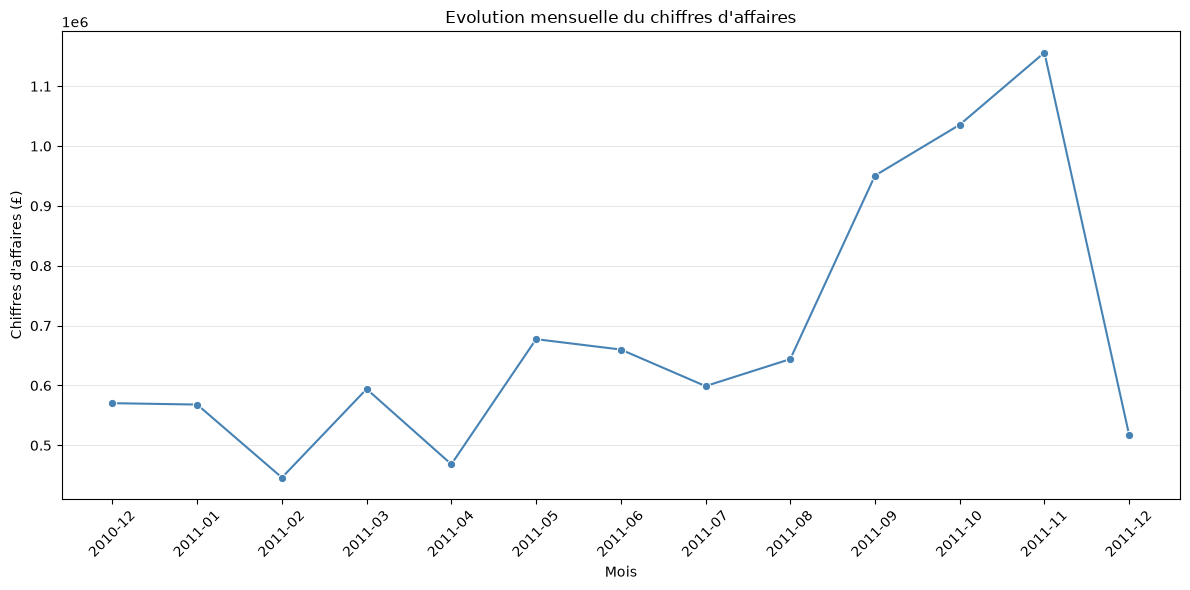

In [9]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthy_sales,
    x="YearMonth",
    y="Revenue",
    marker="o",
    color="steelblue"
)
plt.title("Evolution mensuelle du chiffres d'affaires")
plt.xlabel("Mois")
plt.ylabel("Chiffres d'affaires (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/monthly_sales.png", dpi=300, bbox_inches="tight")

plt.show()

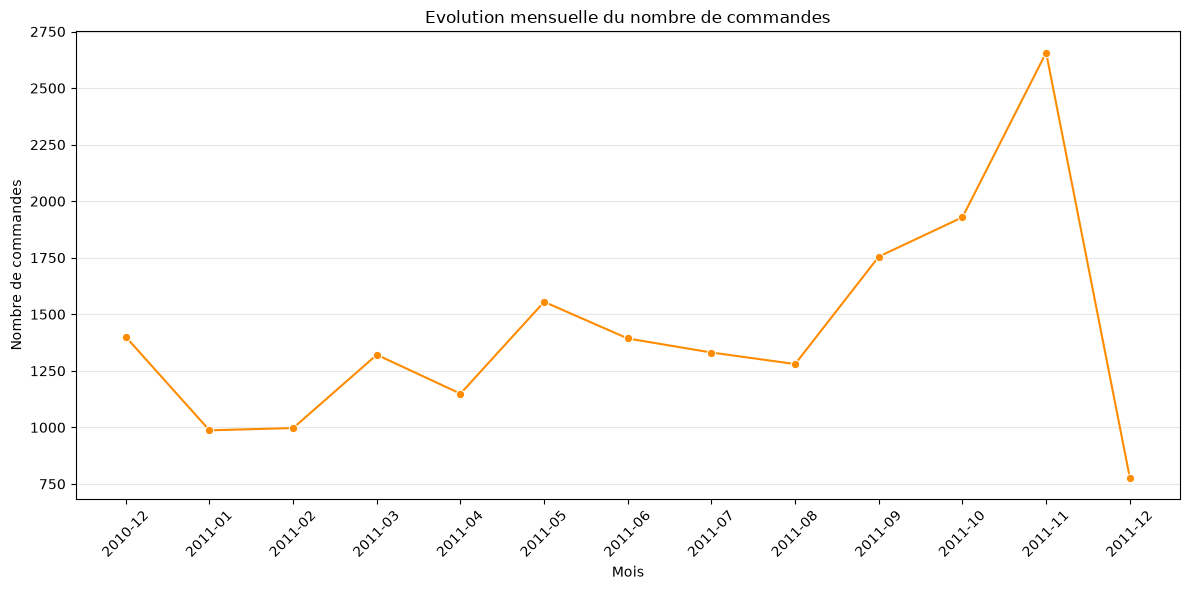

In [10]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthy_sales,
    x="YearMonth",
    y="Orders",
    marker="o",
    color="darkorange"
)
plt.title("Evolution mensuelle du nombre de commandes")
plt.xlabel("Mois")
plt.ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/evolution_commande.png", dpi=300, bbox_inches="tight")

plt.show()

In [11]:
monthy_basket = (
    df_clean.groupby(["YearMonth", "InvoiceNo"], as_index=False)
    .agg(InvoiceTotal=("Revenue", "sum"))
    .groupby("YearMonth", as_index=False)
    .agg(AverageBasket=("InvoiceTotal", "mean"))
)
monthy_basket

,YearMonth,AverageBasket
0,2010-12,407.444807
1,2011-01,575.583901
2,2011-02,447.427202
3,2011-03,449.721241
4,2011-04,407.636493
5,2011-05,435.598167
6,2011-06,473.830617
7,2011-07,450.009693
8,2011-08,503.164875
9,2011-09,541.703819


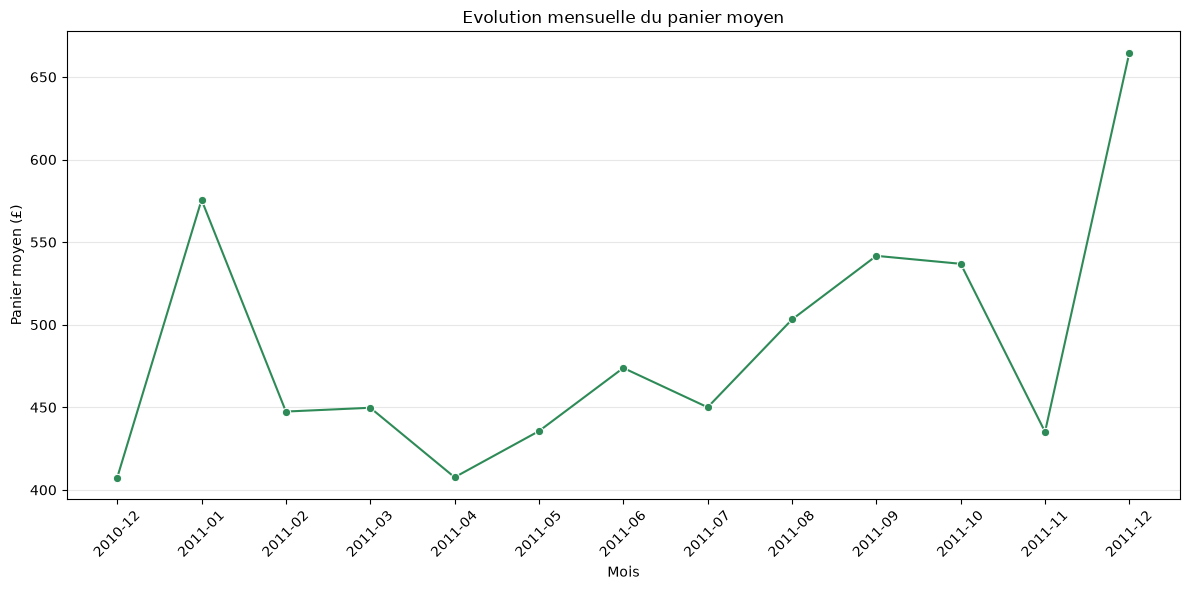

In [12]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthy_basket,
    x="YearMonth",
    y="AverageBasket",
    marker="o",
    color="seagreen"
)
plt.title("Evolution mensuelle du panier moyen")
plt.xlabel("Mois")
plt.ylabel("Panier moyen (£)")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/evolution_panier_moyen.png", dpi=300, bbox_inches="tight")
plt.show()

In [13]:
top_products_quantity = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)
    .agg(TotalQuantity=("Quantity", "sum"))
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
    .sort_values("TotalQuantity", ascending=True)
)
top_products_quantity

,StockCode,Description,TotalQuantity
1383,22492,MINI PAINT SET VINTAGE,26076
2006,23084,RABBIT NIGHT LIGHT,27153
1108,22197,POPCORN HOLDER,30919
432,21212,PACK OF 72 RETROSPOT CAKE CASES,33670
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,35263
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,36706
3444,85099B,JUMBO BAG RED RETROSPOT,46078
3020,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54319
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,77916
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",80995


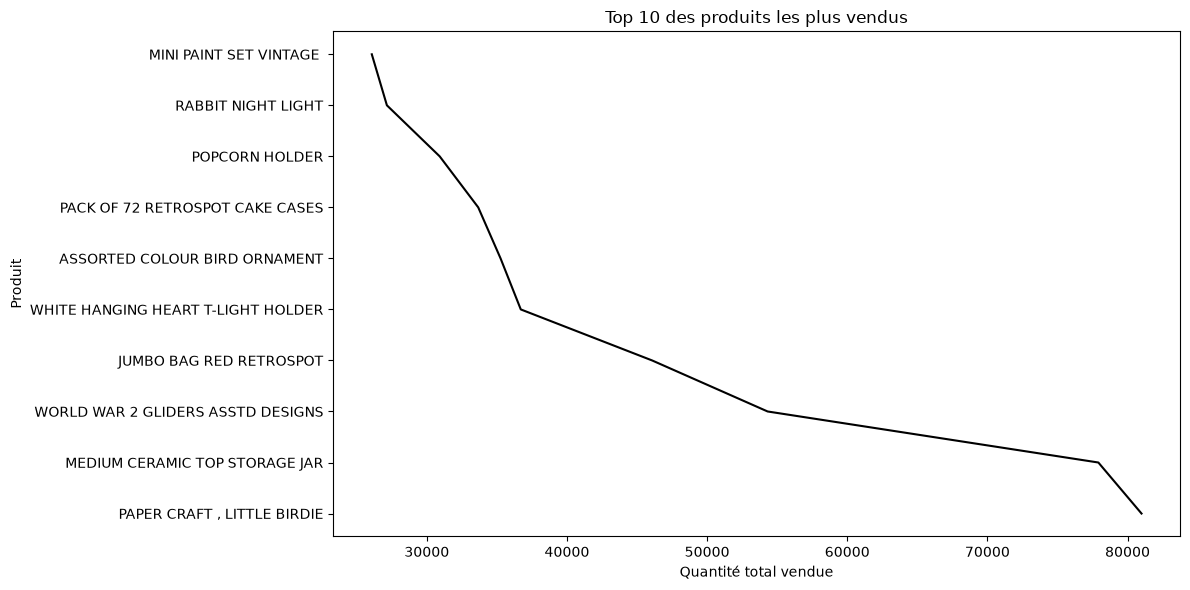

In [14]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=top_products_quantity,
    x="TotalQuantity",
    y="Description",
    color="black"
)
plt.title("Top 10 des produits les plus vendus")
plt.xlabel("Quantité total vendue")
plt.ylabel("Produit")
plt.tight_layout()
plt.savefig("../figures/top_produits_vendus.png", dpi=300, bbox_inches="tight")
plt.show()

In [15]:
top_products_revenue = (
    df_clean.groupby(["StockCode", "Description"], as_index=False)
    .agg(TotalRevenue=("Revenue", "sum"))
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
    .sort_values("TotalRevenue", ascending=True)
)
top_products_revenue

,StockCode,Description,TotalRevenue
2006,23084,RABBIT NIGHT LIGHT,51251.24
3894,M,Manual,53419.93
3278,84879,ASSORTED COLOUR BIRD ORNAMENT,56413.03
2799,47566,PARTY BUNTING,68785.23
3896,POST,POSTAGE,77803.96
2100,23166,MEDIUM CERAMIC TOP STORAGE JAR,81416.73
3444,85099B,JUMBO BAG RED RETROSPOT,85040.54
3459,85123A,WHITE HANGING HEART T-LIGHT HOLDER,100392.10
1318,22423,REGENCY CAKESTAND 3 TIER,142264.75
2602,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60


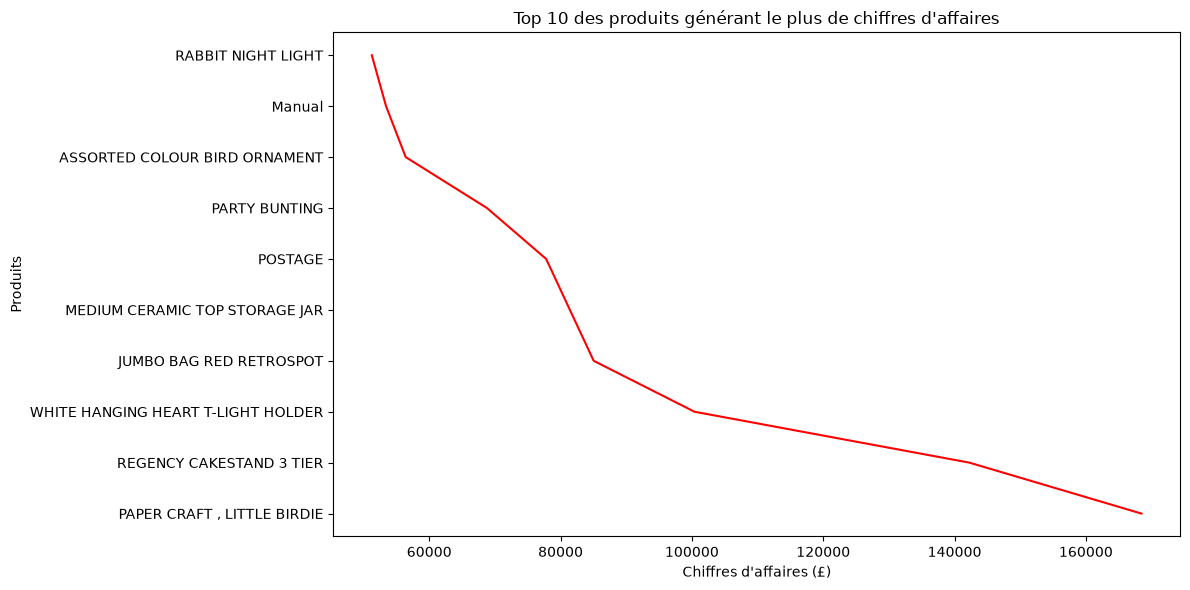

In [16]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=top_products_revenue,
    x="TotalRevenue",
    y="Description",
    color="red"
)
plt.title("Top 10 des produits générant le plus de chiffres d'affaires")
plt.xlabel("Chiffres d'affaires (£)")
plt.ylabel("Produits")
plt.tight_layout()
plt.savefig("../figures/top_produits.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
country_summary=(
    df_clean.groupby("Country", as_index=False)
    .agg(TotalRevenue=("Revenue", "sum"),
         Customers=("CustomerID", "nunique"),
         Orders=("InvoiceNo", "nunique")
        )
)
country_basket=(
    df_clean.groupby(["Country", "InvoiceNo"], as_index=False)
    .agg(InvoiceTotal=("Revenue", "sum"))
    .groupby("Country", as_index=False)
    .agg(AverageBasket=("InvoiceTotal", "mean"))
)
country_summary=(
    country_summary.merge(country_basket, on="Country")
    .sort_values("TotalRevenue", ascending=False)
)
country_summary.head(10)

,Country,TotalRevenue,Customers,Orders,AverageBasket
35,United Kingdom,7285024.644,3920,16646,437.644157
23,Netherlands,285446.340,9,94,3036.663191
10,EIRE,265262.460,3,260,1020.240231
14,Germany,228678.400,94,457,500.390372
13,France,208934.310,87,389,537.106195
0,Australia,138453.810,9,57,2429.014211
30,Spain,61558.560,30,90,683.984000
32,Switzerland,56443.950,21,51,1106.744118
3,Belgium,41196.340,25,98,420.370816
31,Sweden,38367.830,8,36,1065.773056


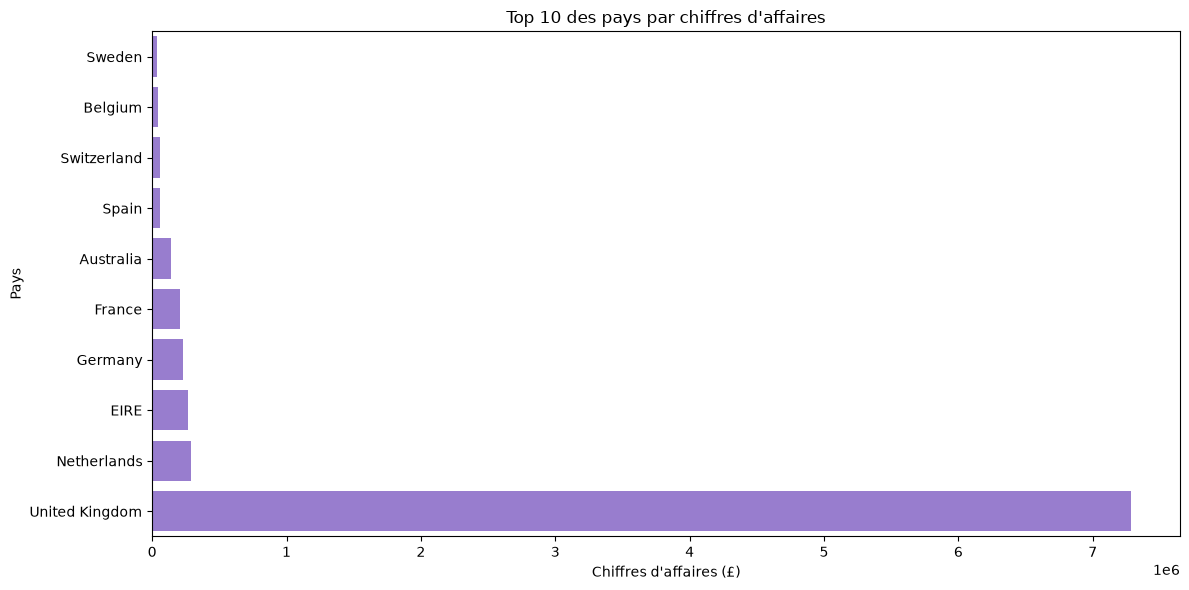

In [18]:
top_countries = (
    country_summary.head(10)
    .sort_values("TotalRevenue", ascending=True)
)
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries,
    x="TotalRevenue",
    y="Country",
    color="mediumpurple"
)
plt.title("Top 10 des pays par chiffres d'affaires")
plt.xlabel("Chiffres d'affaires (£)")
plt.ylabel("Pays")
plt.tight_layout()
plt.savefig("../figures/etop_pays.png", dpi=300, bbox_inches="tight")
plt.show()

In [19]:
customer_summary = (
    df_clean.groupby("CustomerID", as_index=False)
    .agg(TotalRevenue=("Revenue", "sum"),
         Orders=("InvoiceNo", "nunique"),
         TotalQuantity=("Quantity", "sum")
        )
    .sort_values("TotalRevenue", ascending=False)
)

customer_summary.head(10)         

,CustomerID,TotalRevenue,Orders,TotalQuantity
1689,14646,280206.02,73,196915
4201,18102,259657.30,60,64124
3728,17450,194390.79,46,69973
3008,16446,168472.50,2,80997
1879,14911,143711.17,201,80240
55,12415,124914.53,21,77374
1333,14156,117210.08,55,57768
3771,17511,91062.38,31,64549
2702,16029,80850.84,63,40108
0,12346,77183.60,1,74215


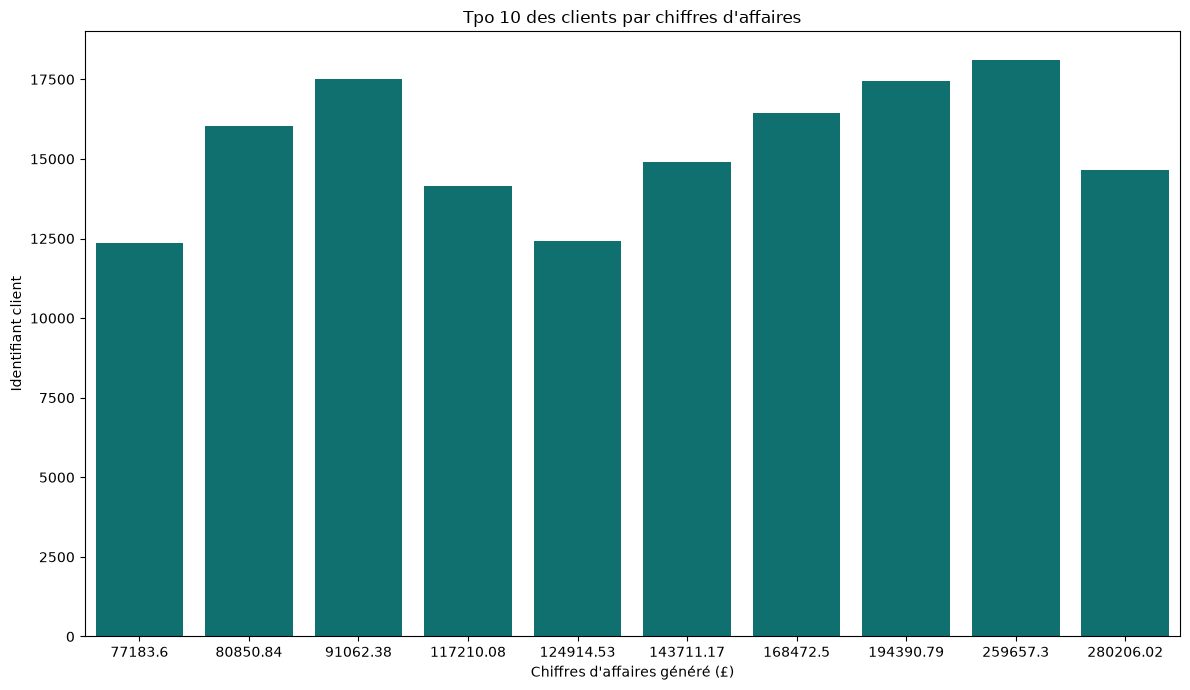

In [20]:
top_customer_revenue = (
    customer_summary.head(10)
    .sort_values("TotalRevenue", ascending=True)
)
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_customer_revenue,
    x="TotalRevenue",
    y="CustomerID",
    color="teal"
)
plt.title("Tpo 10 des clients par chiffres d'affaires")
plt.xlabel("Chiffres d'affaires généré (£)")
plt.ylabel("Identifiant client")
plt.tight_layout()
plt.savefig("../figures/top_client.png", dpi=300, bbox_inches="tight")
plt.show()

In [21]:
top_customers_orders = (
    customer_summary.sort_values("Orders", ascending=False)
    .head(10)
    .sort_values("Orders", ascending=True)
)
top_customers_orders

,CustomerID,TotalRevenue,Orders,TotalQuantity
795,13408,28117.04,62,16232
2702,16029,80850.84,63,40108
1689,14646,280206.02,73,196915
481,12971,11189.91,86,9289
2176,15311,60632.75,91,38147
1661,14606,12076.15,93,6187
562,13089,58762.08,97,31025
4010,17841,40519.84,124,22834
1879,14911,143711.17,201,80240
326,12748,33053.19,209,25287


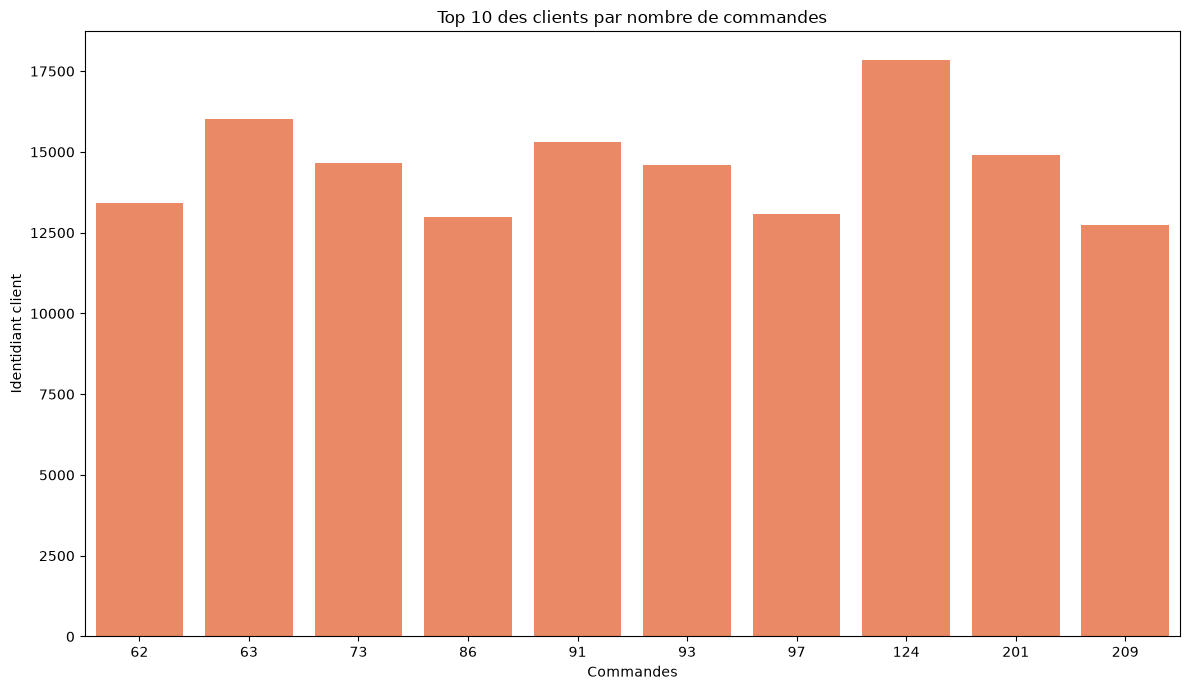

In [22]:
plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_customers_orders,
    x="Orders",
    y="CustomerID",
    color="coral"
)
plt.title("Top 10 des clients par nombre de commandes")
plt.xlabel("Commandes")
plt.ylabel("Identidiant client")
plt.tight_layout()
plt.savefig("../figures/top_client_commande.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
top_customers_quantity = (
    customer_summary.sort_values("TotalQuantity", ascending=False)
    .head(10)
    .sort_values("TotalQuantity", ascending=True)
)
top_customers_quantity

,CustomerID,TotalRevenue,Orders,TotalQuantity
1434,14298,51527.30,44,58343
996,13694,65039.62,50,63312
4201,18102,259657.30,60,64124
3771,17511,91062.38,31,64549
3728,17450,194390.79,46,69973
0,12346,77183.60,1,74215
55,12415,124914.53,21,77374
1879,14911,143711.17,201,80240
3008,16446,168472.50,2,80997
1689,14646,280206.02,73,196915


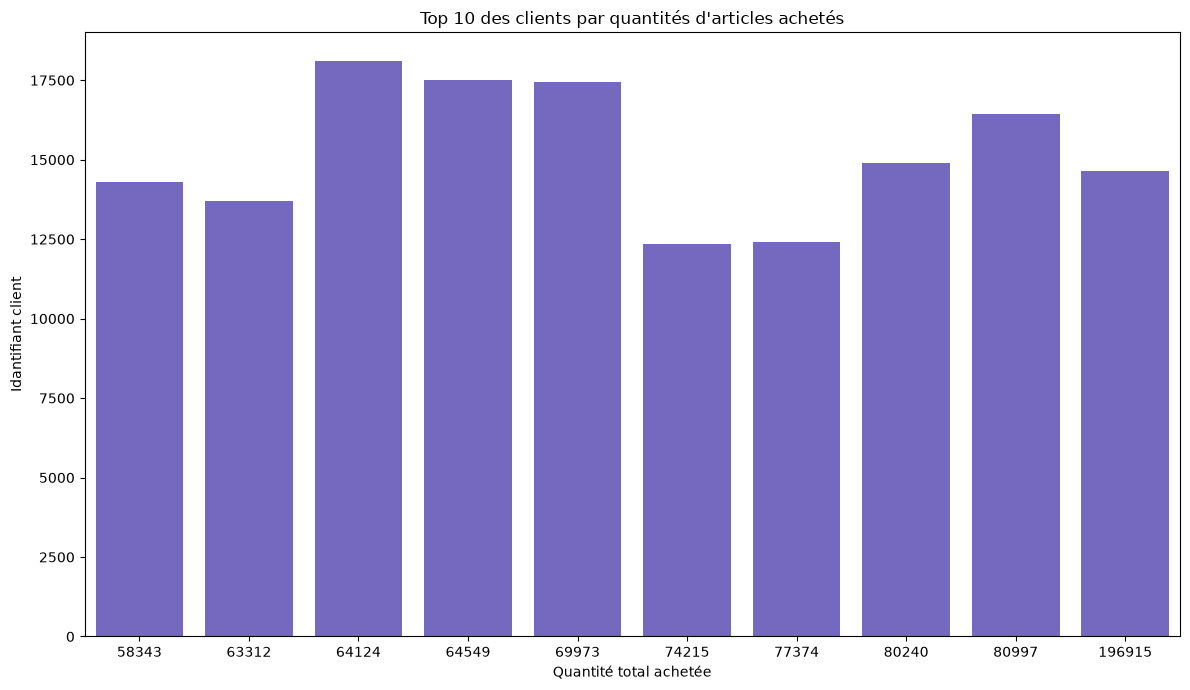

In [24]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_customers_quantity,
    x="TotalQuantity",
    y="CustomerID",
    color="slateblue"
)
plt.title("Top 10 des clients par quantités d'articles achetés")
plt.xlabel("Quantité total achetée")
plt.ylabel("Idantifiant client")
plt.tight_layout()
plt.savefig("../figures/top_client_quantites.png", dpi=300, bbox_inches="tight")
plt.show()

In [25]:
reference_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    df_clean.groupby("CustomerID", as_index=False)
    .agg(LastPurchase=("InvoiceDate", "max"),
         Frequency=("InvoiceNo", "nunique"),
         Monetary=("Revenue", "sum")
        )
)
rfm["Recency"] = (reference_date - rfm["LastPurchase"]).dt.days
rfm = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [26]:
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = rfm["R_Score"] + rfm["F_Score"] + rfm["M_Score"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,7
1,12347,2,7,4310.00,5,5,5,15
2,12348,75,4,1797.24,2,4,4,10
3,12349,19,1,1757.55,4,1,4,9
4,12350,310,1,334.40,1,1,2,4


In [27]:
conditions = [
    (rfm["R_Score"] >= 4) &
    (rfm["F_Score"] >= 4) &
    (rfm["M_Score"] >= 4),

    (rfm["R_Score"] >= 3) &
    (rfm["F_Score"] >= 3) &
    (rfm["M_Score"] >= 3),

    (rfm["R_Score"] >= 4),

    (rfm["R_Score"] <= 2) &
    (rfm["F_Score"] >= 3),

    (rfm["R_Score"] <= 2) &
    (rfm["F_Score"] <= 2)
]

segments = [
    "VIP",
    "Fidèles",
    "Récents",
    "À risque",
    "Inactifs"
]

rfm["Segment"] = np.select(
    conditions,
    segments,
    default="À développer"
)

rfm[["CustomerID", "Recency", "Frequency", "Monetary", "RFM_Score", "Segment"]].head()

,CustomerID,Recency,Frequency,Monetary,RFM_Score,Segment
0,12346,326,1,77183.60,7,Inactifs
1,12347,2,7,4310.00,15,VIP
2,12348,75,4,1797.24,10,À risque
3,12349,19,1,1757.55,9,Récents
4,12350,310,1,334.40,4,Inactifs


In [28]:
segment_summary = (
    rfm["Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = ["Segment", "NumberOfCustomers"]

segment_summary

,Segment,NumberOfCustomers
0,Inactifs,1074
1,VIP,942
2,Fidèles,767
3,À risque,661
4,Récents,459
5,À développer,435


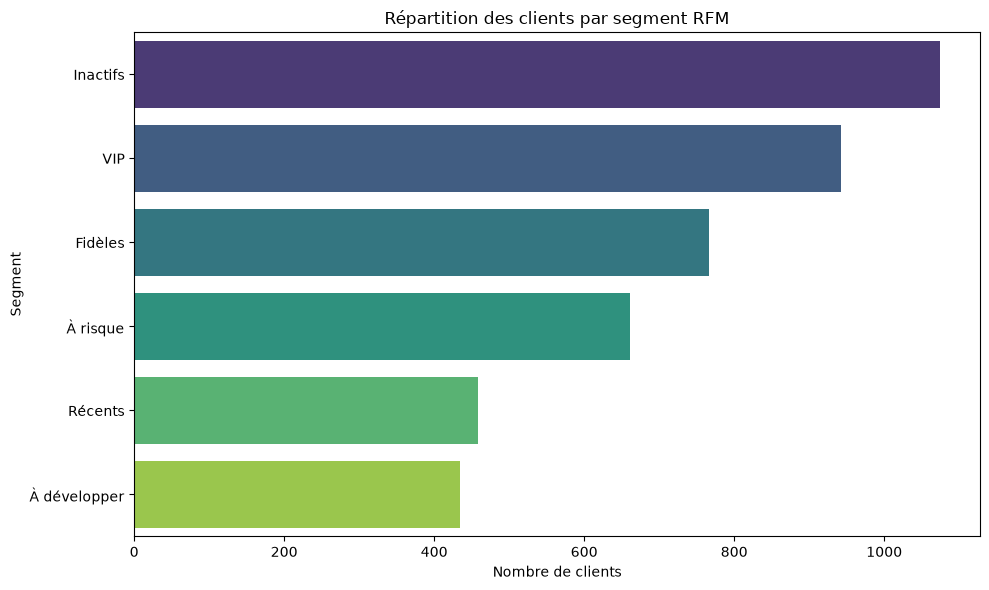

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=segment_summary,
    x="NumberOfCustomers",
    y="Segment",
    hue="Segment",
    palette="viridis",
    legend=False
)

plt.title("Répartition des clients par segment RFM")
plt.xlabel("Nombre de clients")
plt.ylabel("Segment")
plt.tight_layout()
plt.savefig("../figures/repartition_client_RFM.png", dpi=300, bbox_inches="tight")
plt.show()

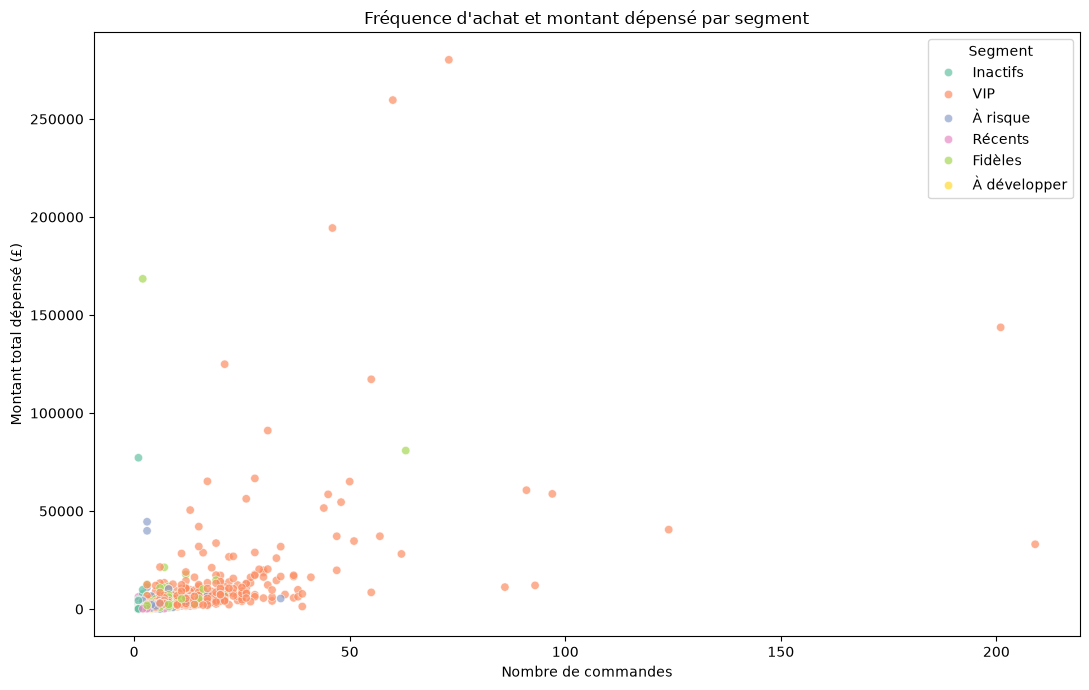

In [30]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    alpha=0.7,
    palette="Set2"
)

plt.title("Fréquence d'achat et montant dépensé par segment")
plt.xlabel("Nombre de commandes")
plt.ylabel("Montant total dépensé (£)")
plt.legend(title="Segment")
plt.tight_layout()
plt.savefig("../figures/frequence_achat.png", dpi=300, bbox_inches="tight")
plt.show()

In [31]:
best_month = monthy_sales.loc[monthy_sales["Revenue"].idxmax()]
lowest_month = monthy_sales.loc[monthy_sales["Revenue"].idxmin()]

best_product_quantity = top_products_quantity.loc[
    top_products_quantity["TotalQuantity"].idxmax()
]

best_product_revenue = top_products_revenue.loc[
    top_products_revenue["TotalRevenue"].idxmax()
]

best_country = country_summary.loc[
    country_summary["TotalRevenue"].idxmax()
]

print("Meilleur mois :", best_month["YearMonth"])
print(f"Chiffre d'affaires : {best_month['Revenue']:,.2f} £")

print("\nMois le plus faible :", lowest_month["YearMonth"])
print(f"Chiffre d'affaires : {lowest_month['Revenue']:,.2f} £")

print("\nProduit le plus vendu :")
print(best_product_quantity["Description"])
print(f"Quantité : {best_product_quantity['TotalQuantity']:,.0f}")

print("\nProduit générant le plus de chiffre d'affaires :")
print(best_product_revenue["Description"])
print(f"Chiffre d'affaires : {best_product_revenue['TotalRevenue']:,.2f} £")

print("\nPrincipal marché :")
print(best_country["Country"])
print(f"Chiffre d'affaires : {best_country['TotalRevenue']:,.2f} £")

print("\nRépartition des segments :")
print(segment_summary)

Meilleur mois : 2011-11
Chiffre d'affaires : 1,156,205.61 £

Mois le plus faible : 2011-02
Chiffre d'affaires : 446,084.92 £

Produit le plus vendu :
PAPER CRAFT , LITTLE BIRDIE
Quantité : 80,995

Produit générant le plus de chiffre d'affaires :
PAPER CRAFT , LITTLE BIRDIE
Chiffre d'affaires : 168,469.60 £

Principal marché :
United Kingdom
Chiffre d'affaires : 7,285,024.64 £

Répartition des segments :
        Segment  NumberOfCustomers
0      Inactifs               1074
1           VIP                942
2       Fidèles                767
3      À risque                661
4       Récents                459
5  À développer                435


In [32]:
segment_business = (
    rfm
    .groupby("Segment", as_index=False)
    .agg(
        NumberOfCustomers=("CustomerID", "count"),
        TotalRevenue=("Monetary", "sum"),
        AverageRevenue=("Monetary", "mean"),
        AverageFrequency=("Frequency", "mean")
    )
    .sort_values("TotalRevenue", ascending=False)
)

segment_business["RevenueShare"] = (
    segment_business["TotalRevenue"]
    / segment_business["TotalRevenue"].sum()
    * 100
)

segment_business

,Segment,NumberOfCustomers,TotalRevenue,AverageRevenue,AverageFrequency,RevenueShare
3,VIP,942,5737952.120,6091.244289,11.197452,64.564164
0,Fidèles,767,1426427.131,1859.748541,4.160365,16.050339
5,À risque,661,823912.441,1246.463602,3.413011,9.270767
1,Inactifs,1074,523803.282,487.712553,1.101490,5.893901
2,Récents,459,189972.760,413.884009,1.633987,2.137598
4,À développer,435,185141.160,425.611862,1.388506,2.083232


In [33]:
dashboard_kpis = pd.DataFrame({
    "Indicateur": [
        "Chiffre d'affaires total",
        "Nombre de commandes",
        "Nombre de clients",
        "Panier moyen"
    ],
    "Valeur": [
        f"{df_clean['Revenue'].sum():,.2f} £",
        f"{order_df['InvoiceNo'].nunique():,.0f}",
        f"{df_clean['CustomerID'].nunique():,.0f}",
        f"{order_df['InvoiceTotal'].mean():,.2f} £"
    ]
})

dashboard_kpis

,Indicateur,Valeur
0,Chiffre d'affaires total,"8,887,208.89 £"
1,Nombre de commandes,"18,532"
2,Nombre de clients,"4,338"
3,Panier moyen,479.56 £


# Business Insights

## Observation 1 — Évolution des ventes
- **Donnée :** Le chiffre d'affaires atteint son maximum en **[mois]**, avec **[montant] £**.
- **Observation :** Les ventes présentent une période de forte activité.
- **Interprétation :** L'activité semble soumise à une saisonnalité.
- **Recommandation :** Prévoir davantage de stock et renforcer les actions marketing avant cette période.

## Observation 2 — Produits
- **Donnée :** Le produit le plus vendu est **[produit]**, tandis que le produit générant le plus de chiffre d'affaires est **[produit]**.
- **Observation :** Les deux produits ne sont pas nécessairement identiques.
- **Interprétation :** Les volumes de vente et le chiffre d'affaires doivent être analysés séparément.
- **Recommandation :** Mettre en avant les produits à forte valeur et sécuriser le stock des produits très demandés.

## Observation 3 — Marchés géographiques
- **Donnée :** Le principal marché est **[pays]**, avec **[montant] £** de chiffre d'affaires.
- **Observation :** Le chiffre d'affaires est concentré sur certains pays.
- **Interprétation :** L'entreprise dépend fortement de ses marchés principaux.
- **Recommandation :** Développer les pays secondaires les plus prometteurs afin de réduire cette dépendance.

## Observation 4 — Clients
- **Donnée :** Les meilleurs clients génèrent une part importante du chiffre d'affaires.
- **Observation :** La valeur commerciale est concentrée sur un nombre limité de clients.
- **Interprétation :** Ces clients doivent être fidélisés en priorité.
- **Recommandation :** Mettre en place des offres personnalisées ou un programme de fidélité.

## Observation 5 — Segmentation RFM
- **Donnée :** Le segment **[segment]** contient **[nombre]** clients et représente **[pourcentage] %** du chiffre d'affaires.
- **Observation :** Les segments n'ont pas la même valeur commerciale.
- **Interprétation :** Une stratégie unique pour tous les clients serait inefficace.
- **Recommandation :** Adapter les campagnes selon le segment : fidélisation des VIP, réactivation des clients à risque et conversion des récents.

# Analyse des ventes e-commerce

## 1. Chargement des données

## 2. Compréhension et qualité des données

## 3. Nettoyage des données

## 4. Feature Engineering

## 5. Indicateurs clés de performance

## 6. Analyse temporelle

## 7. Analyse des produits

## 8. Analyse géographique

## 9. Analyse clients

## 10. Segmentation RFM

## 11. Business Insights et recommandations

## 12. Dashboard